<a href="https://colab.research.google.com/github/Ashishjoshi794/Dog-and-Cat-Classification/blob/main/Dog_and_Cat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Data Collection and Exploration

✓ Dataset loaded
✓ Folder structure checked
✓ Cat images counted
✓ Dog images counted
✓ Sample Cat images displayed
✓ Sample Dog images displayed
✓ Class distribution analyzed
✓ Image dimensions checked
✓ Corrupted images detected
✓ Corrupted images removed

In [ ]:
!pip install kaggle

In [ ]:
!kaggle --version

Kaggle CLI 2.0.2


In [ ]:
!kaggle datasets download -d karakaggle/kaggle-cat-vs-dog-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/karakaggle/kaggle-cat-vs-dog-dataset
License(s): unknown
100% 787M/787M [00:50<00:00, 16.4MB/s]



In [ ]:
import os

os.listdir()

['.config', 'kagglecatsanddogs_3367a', 'sample_data']

In [ ]:
os.listdir("kagglecatsanddogs_3367a")

['readme[1].txt', 'PetImages', 'MSR-LA - 3467.docx']

In [ ]:
# Import required libraries

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# Location of our dataset

dataset_path = "/content/kagglecatsanddogs_3367a/PetImages"

cat_path = os.path.join(dataset_path, "Cat")
dog_path = os.path.join(dataset_path, "Dog")

print("Cat folder:", cat_path)
print("Dog folder:", dog_path)

Cat folder: /content/kagglecatsanddogs_3367a/PetImages/Cat
Dog folder: /content/kagglecatsanddogs_3367a/PetImages/Dog


In [ ]:
# Check whether Cat and Dog folders exist

print("Dataset exists:", os.path.exists(dataset_path))
print("Cat folder exists:", os.path.exists(cat_path))
print("Dog folder exists:", os.path.exists(dog_path))

Dataset exists: True
Cat folder exists: True
Dog folder exists: True


In [ ]:
# Get all files from Cat and Dog folders

cat_images = os.listdir(cat_path)
dog_images = os.listdir(dog_path)

print("Number of Cat files:", len(cat_images))
print("Number of Dog files:", len(dog_images))

Number of Cat files: 12491
Number of Dog files: 12470


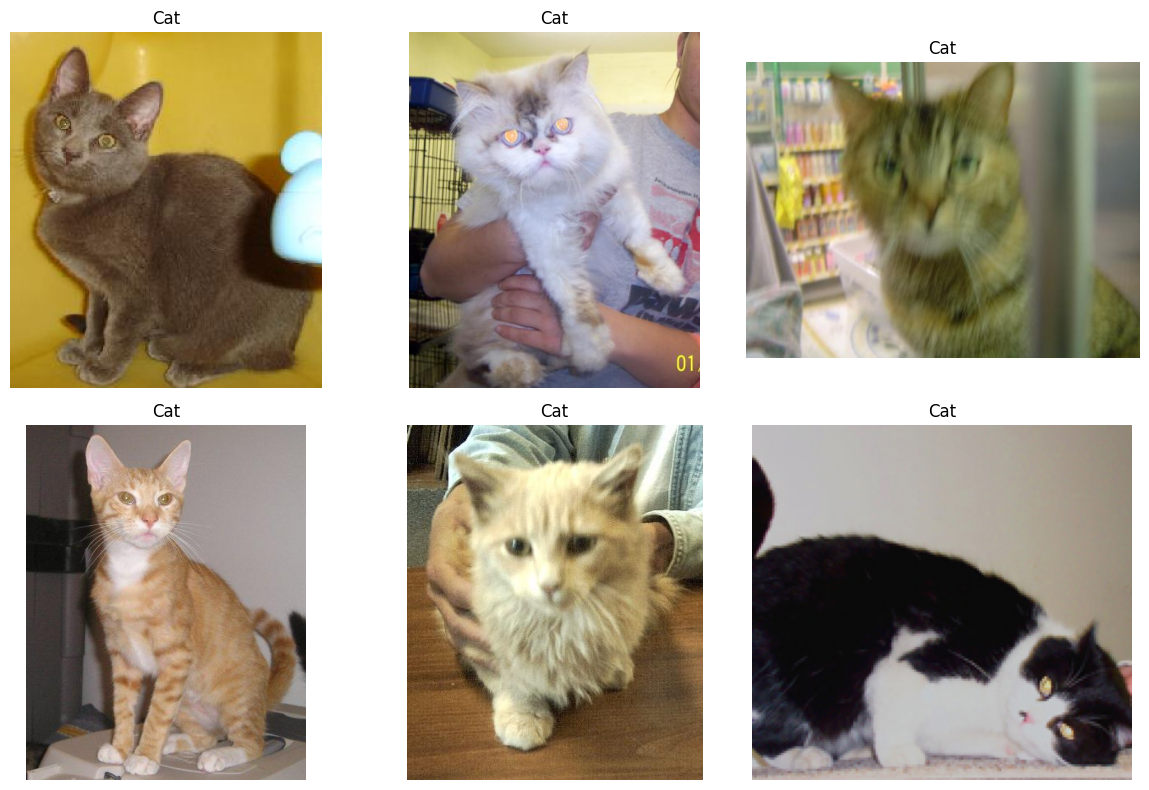

In [ ]:
# Display some sample Cat images

plt.figure(figsize=(12, 8))

for i in range(6):

    # Select a random Cat image
    image_name = random.choice(cat_images)

    image_path = os.path.join(cat_path, image_name)

    try:
        image = Image.open(image_path)

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.title("Cat")
        plt.axis("off")

    except:
        pass

plt.tight_layout()
plt.show()

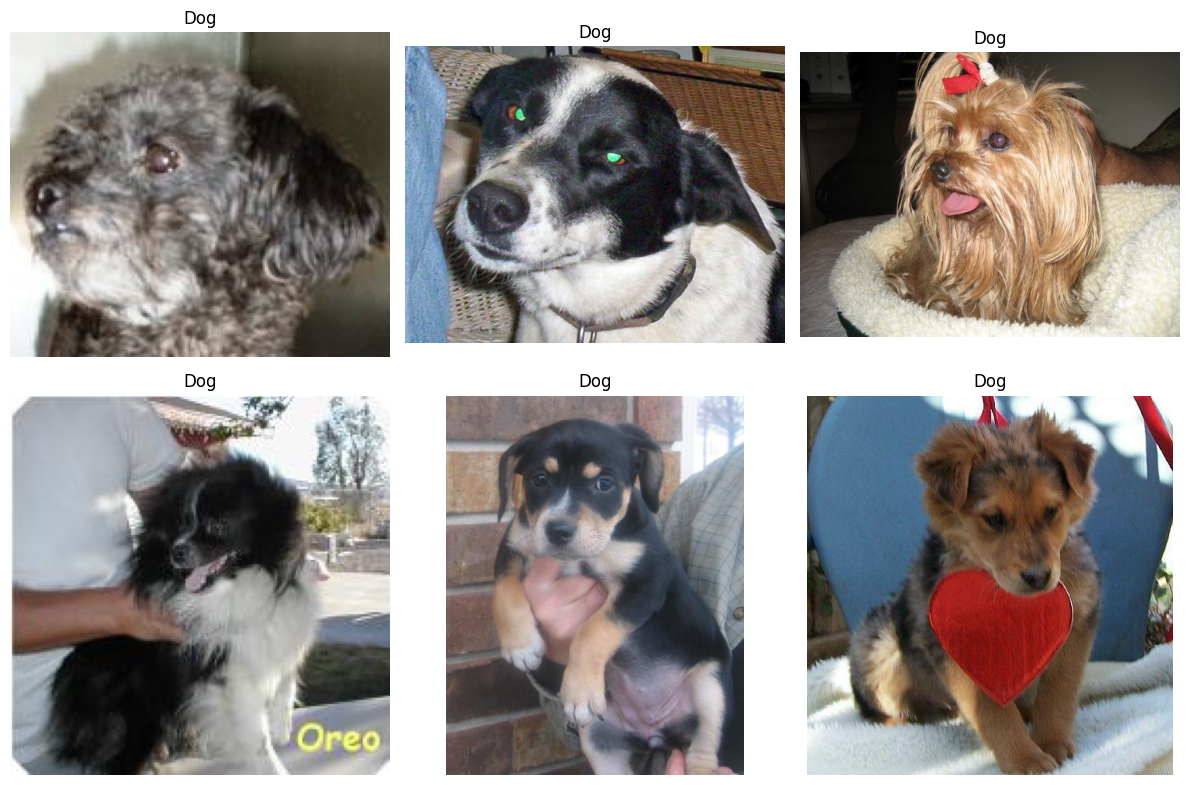

In [ ]:
# Display some sample Dog images

plt.figure(figsize=(12, 8))

for i in range(6):

    # Select a random Dog image
    image_name = random.choice(dog_images)

    image_path = os.path.join(dog_path, image_name)

    try:
        image = Image.open(image_path)

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.title("Dog")
        plt.axis("off")

    except:
        pass

plt.tight_layout()
plt.show()

In [ ]:
# Create class distribution table

class_distribution = pd.DataFrame({
    "Class": ["Cat", "Dog"],
    "Number of Images": [len(cat_images), len(dog_images)]
})

class_distribution

,Class,Number of Images
0,Cat,12491
1,Dog,12470


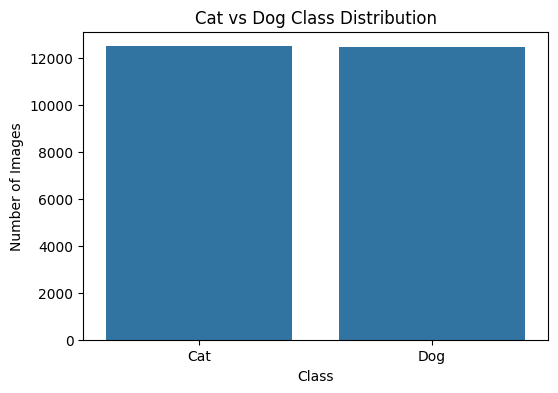

In [ ]:
# Display class distribution

plt.figure(figsize=(6, 4))

sns.barplot(
    x="Class",
    y="Number of Images",
    data=class_distribution
)

plt.title("Cat vs Dog Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [ ]:
# Check the size of some Cat images

for image_name in cat_images[:10]:

    image_path = os.path.join(cat_path, image_name)

    try:
        image = Image.open(image_path)
        print(image_name, "->", image.size)

    except:
        print(image_name, "-> Cannot open")

10614.jpg -> (375, 500)
2834.jpg -> (470, 374)
9082.jpg -> (500, 375)
4576.jpg -> (361, 360)
4190.jpg -> (246, 320)
6806.jpg -> (500, 375)
2631.jpg -> (320, 240)
5589.jpg -> (500, 423)
6379.jpg -> (466, 500)
2656.jpg -> (412, 401)


In [ ]:
# Function to find corrupted images

def find_corrupted_images(folder_path):

    corrupted_images = []

    # Get all files
    files = os.listdir(folder_path)

    for file_name in files:

        file_path = os.path.join(folder_path, file_name)

        try:
            # Open the image
            image = Image.open(file_path)

            # Check whether the image is actually valid
            image.verify()

        except:
            # Add corrupted file to the list
            corrupted_images.append(file_path)

    return corrupted_images

In [ ]:
# Check Cat images

corrupted_cats = find_corrupted_images(cat_path)

# Check Dog images

corrupted_dogs = find_corrupted_images(dog_path)

print("Corrupted Cat images:", len(corrupted_cats))
print("Corrupted Dog images:", len(corrupted_dogs))

Corrupted Cat images: 1
Corrupted Dog images: 1


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [ ]:
# Remove corrupted Cat images

for image_path in corrupted_cats:
    os.remove(image_path)

# Remove corrupted Dog images

for image_path in corrupted_dogs:
    os.remove(image_path)

print("Corrupted images removed successfully.")

Corrupted images removed successfully.


In [ ]:
cat_images = os.listdir(cat_path)
dog_images = os.listdir(dog_path)

print("Cat images after cleaning:", len(cat_images))
print("Dog images after cleaning:", len(dog_images))

Cat images after cleaning: 12490
Dog images after cleaning: 12469


In [ ]:
# Check images and find images that are not RGB, grayscale, or RGBA

def find_invalid_channel_images(folder_path):

    invalid_images = []

    # Get all files in the folder
    files = os.listdir(folder_path)

    for file_name in files:

        file_path = os.path.join(folder_path, file_name)

        try:
            # Open the image
            image = Image.open(file_path)

            # Get the image mode
            mode = image.mode

            # Accept only RGB, L (grayscale), or RGBA images
            if mode not in ["RGB", "L", "RGBA"]:
                invalid_images.append(file_path)

        except:
            # If image cannot be opened
            invalid_images.append(file_path)

    return invalid_images

In [ ]:
# Check Cat images

invalid_cats = find_invalid_channel_images(cat_path)

# Check Dog images

invalid_dogs = find_invalid_channel_images(dog_path)

print("Invalid Cat images:", len(invalid_cats))
print("Invalid Dog images:", len(invalid_dogs))

Invalid Cat images: 25
Invalid Dog images: 29


In [ ]:
# Display the invalid image paths

print("Invalid Cat images:")
for image_path in invalid_cats:
    print(image_path)

print("\nInvalid Dog images:")
for image_path in invalid_dogs:
    print(image_path)

Invalid Cat images:
/content/kagglecatsanddogs_3367a/PetImages/Cat/11565.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/5370.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/7978.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/2663.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/6435.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/936.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/8470.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/850.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/10125.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/3300.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/9778.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/11095.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/7968.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/11210.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/140.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/4833.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/10820.jpg
/content/kagglecatsanddogs

In [ ]:
# Remove invalid Cat images

for image_path in invalid_cats:
    os.remove(image_path)

# Remove invalid Dog images

for image_path in invalid_dogs:
    os.remove(image_path)

print("Invalid images removed successfully.")

Invalid images removed successfully.


In [ ]:
# Count images after cleaning

cat_images = os.listdir(cat_path)
dog_images = os.listdir(dog_path)

print("Cat images:", len(cat_images))
print("Dog images:", len(dog_images))

Cat images: 12465
Dog images: 12440


Step 2: Data Preprocessing

✓ Resize images to 224 × 224
✓ Normalize pixel values 0–255 → 0–1
✓ Rotation
✓ Horizontal Flip
✓ Zoom
✓ Width Shift
✓ Height Shift
✓ Train = 70%
✓ Validation = 15%
✓ Test = 15%

In [ ]:
# Image height
IMAGE_HEIGHT = 224

# Image width
IMAGE_WIDTH = 224

# Number of images processed at one time
BATCH_SIZE = 32

print("Image size:", IMAGE_HEIGHT, "x", IMAGE_WIDTH)
print("Batch size:", BATCH_SIZE)

Image size: 224 x 224
Batch size: 32


In [ ]:
# Dataset path

dataset_path = "/content/kagglecatsanddogs_3367a/PetImages"

print(dataset_path)

/content/kagglecatsanddogs_3367a/PetImages


In [ ]:
# Load 70% of the dataset for training

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="binary",
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    validation_split=0.30,
    subset="training",
    seed=42
)

print("Training dataset loaded successfully.")

Found 24905 files belonging to 2 classes.
Using 17434 files for training.
Training dataset loaded successfully.


In [ ]:
# Load the remaining 30% of the dataset

validation_test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="binary",
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    validation_split=0.30,
    subset="validation",
    seed=42
)

print("Validation/Test dataset loaded successfully.")

Found 24905 files belonging to 2 classes.
Using 7471 files for validation.
Validation/Test dataset loaded successfully.


In [ ]:
# Count the number of batches in the temporary dataset

total_batches = tf.data.experimental.cardinality(
    validation_test_dataset
).numpy()

print("Total batches:", total_batches)

Total batches: 234


In [ ]:
# Calculate half of the batches

half_batches = total_batches // 2

print("Half batches:", half_batches)

Half batches: 117


In [ ]:
# First half = validation dataset

validation_dataset = validation_test_dataset.take(half_batches)

print("Validation dataset created.")

Validation dataset created.


In [ ]:
# Second half = test dataset

test_dataset = validation_test_dataset.skip(half_batches)

print("Test dataset created.")

Test dataset created.


In [ ]:
print("Training batches:",
      tf.data.experimental.cardinality(train_dataset).numpy())

print("Validation batches:",
      tf.data.experimental.cardinality(validation_dataset).numpy())

print("Test batches:",
      tf.data.experimental.cardinality(test_dataset).numpy())

Training batches: 545
Validation batches: 117
Test batches: 117


In [ ]:
# Display the class names

class_names = train_dataset.class_names

print("Classes:", class_names)

Classes: ['Cat', 'Dog']


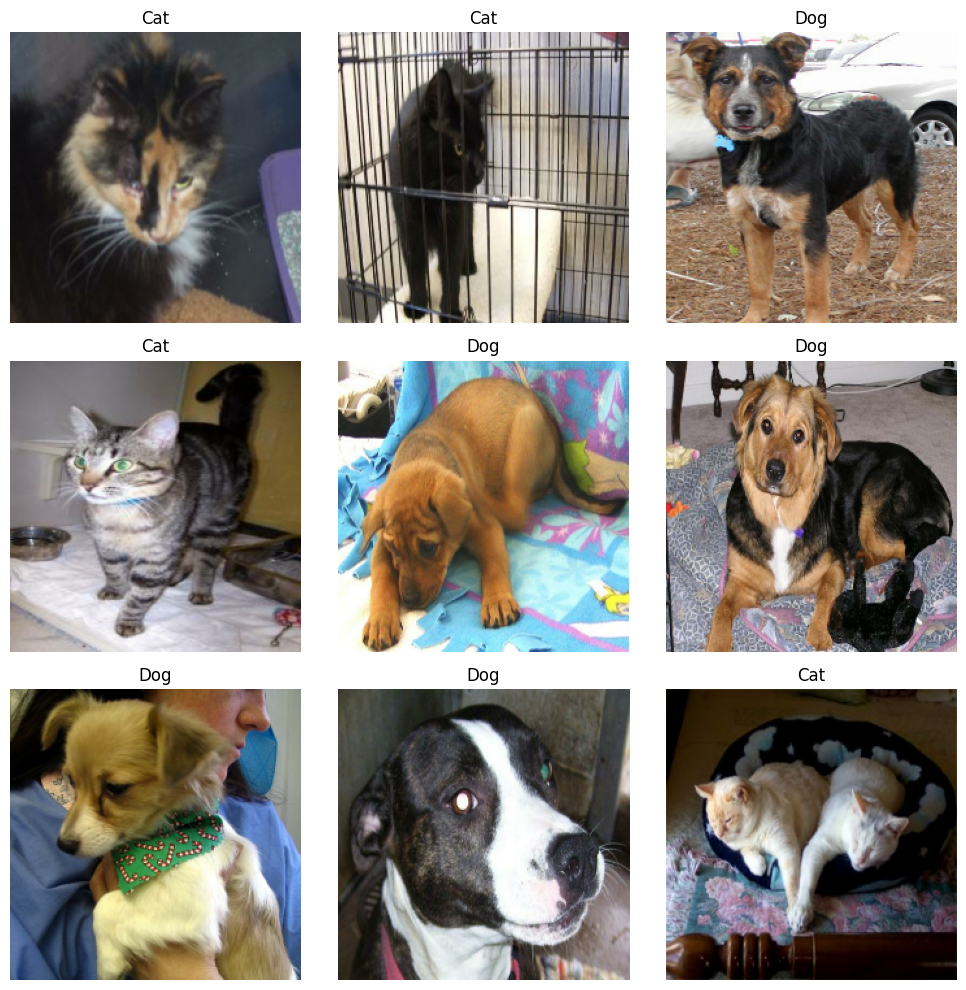

In [ ]:
# Display some images from the training dataset

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        # Display image
        plt.imshow(images[i].numpy().astype("uint8"))

        # Get the class name
        label = int(labels[i].numpy()[0])

        plt.title(class_names[label])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Check the shape of one batch of images

for images, labels in train_dataset.take(1):

    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

Image shape: (32, 224, 224, 3)
Label shape: (32, 1)


Normalize Pixel Values

In [ ]:
# Create a normalization layer

normalization_layer = layers.Rescaling(
    1.0 / 255
)

In [ ]:
# Take one batch of images

for images, labels in train_dataset.take(1):

    # Normalize the images
    normalized_images = normalization_layer(images)

    print("Original minimum:", tf.reduce_min(images).numpy())
    print("Original maximum:", tf.reduce_max(images).numpy())

    print("Normalized minimum:", tf.reduce_min(normalized_images).numpy())
    print("Normalized maximum:", tf.reduce_max(normalized_images).numpy())

Original minimum: 0.0
Original maximum: 255.0
Normalized minimum: 0.0
Normalized maximum: 1.0


#Data Augmentation
Rotation\
Horizontal Flip\
Zoom\
Width Shift\
Height Shift\

RandomRotation
       ↓
Rotates the image slightly

RandomFlip
       ↓
Flips image left ↔ right

RandomZoom
       ↓
Zooms in/out slightly

RandomTranslation width
       ↓
Moves image left/right

RandomTranslation height
       ↓
Moves image up/down

In [ ]:
# Import Sequential model from Keras

from tensorflow.keras.models import Sequential

In [ ]:
# Create data augmentation

data_augmentation = Sequential([

    # Randomly rotate the image
    layers.RandomRotation(0.1),

    # Flip image horizontally
    layers.RandomFlip("horizontal"),

    # Random zoom
    layers.RandomZoom(0.1),

    # Randomly move image horizontally
    layers.RandomTranslation(
        height_factor=0.0,
        width_factor=0.1
    ),

    # Randomly move image vertically
    layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.0
    )
])

print("Data augmentation created successfully.")

Data augmentation created successfully.


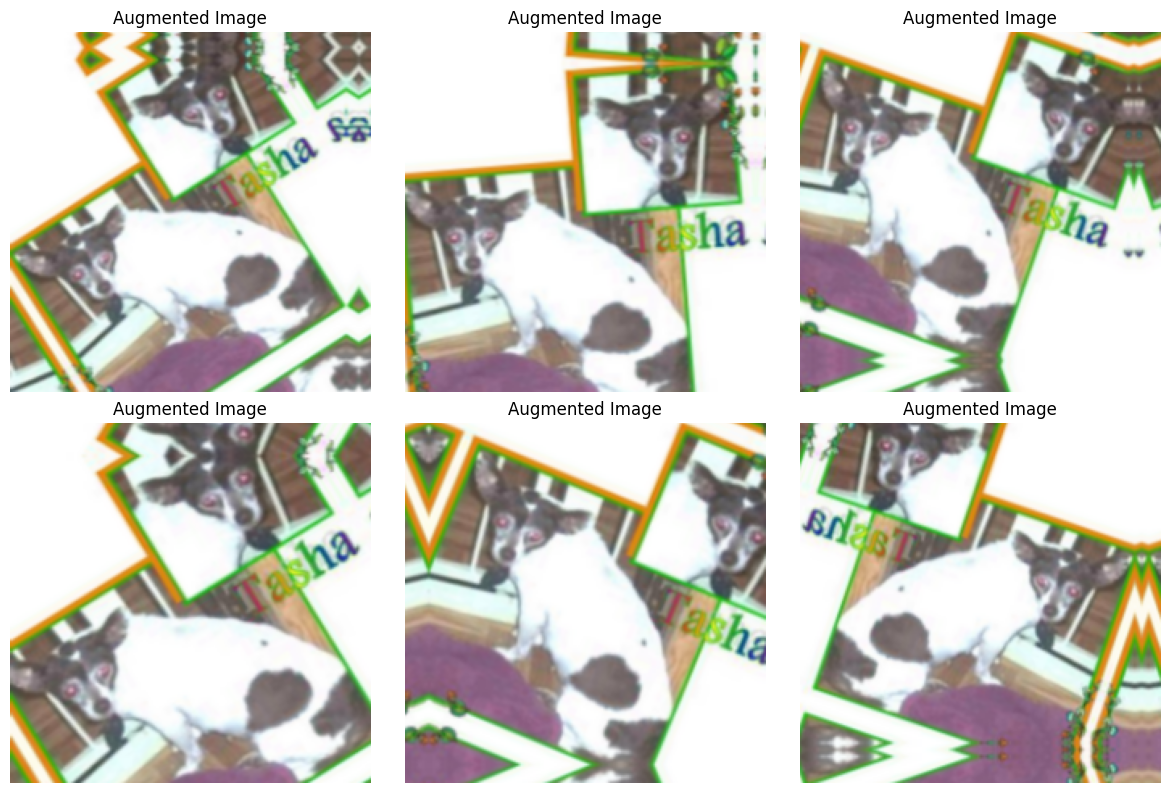

In [ ]:
# Get one batch of images

for images, labels in train_dataset.take(1):

    # Select one image
    sample_image = images[0]

    plt.figure(figsize=(12, 8))

    for i in range(6):

        # Apply augmentation
        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, 0)
        )

        plt.subplot(2, 3, i + 1)

        plt.imshow(
            augmented_image[0].numpy().astype("uint8")
        )

        plt.title("Augmented Image")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# Improve dataset performance

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

print("Dataset preparation completed.")

Dataset preparation completed.


MODEL DEVELOPMENT

In [ ]:
print(class_names)

['Cat', 'Dog']


#CUSTOM CNN
Conv2D\
ReLU\
MaxPooling\
Conv2D\
MaxPooling\
Flatten\
Dense\
Dropout\
Sigmoid Output

Input Image
224 × 224 × 3
       ↓
Data Augmentation
       ↓
Normalization
       ↓
Conv2D + ReLU
       ↓
MaxPooling
       ↓
Conv2D + ReLU
       ↓
MaxPooling
       ↓
Flatten
       ↓
Dense
       ↓
Dropout
       ↓
Sigmoid
       ↓
Cat / Dog

In [ ]:
# Create Custom CNN model

custom_cnn = Sequential([

    # Data augmentation
    data_augmentation,

    # Normalize pixel values from 0-255 to 0-1
    normalization_layer,

    # First convolution layer
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(224, 224, 3)
    ),

    # Reduce image size
    layers.MaxPooling2D(
        (2, 2)
    ),

    # Second convolution layer
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Reduce image size again
    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convert feature maps into one-dimensional data
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout helps reduce overfitting
    layers.Dropout(0.5),

    # Output layer
    # 1 means binary classification: Cat or Dog
    layers.Dense(
        1,
        activation="sigmoid"
    )
])

print("Custom CNN created successfully.")

Custom CNN created successfully.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Display the structure of the CNN

custom_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 222, 222, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 111, 111, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 109, 109, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 54, 54, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 186624)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 1)                 │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the Custom CNN

custom_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Custom CNN compiled successfully.")

Custom CNN compiled successfully.


In [ ]:
# Import EarlyStopping

from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Create EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
# Check and clean all Cat and Dog images

from PIL import Image
import os

def clean_images(folder_path):

    # Count removed images
    removed_count = 0

    # Get all files in the folder
    files = os.listdir(folder_path)

    for file_name in files:

        file_path = os.path.join(folder_path, file_name)

        try:
            # Open the image
            image = Image.open(file_path)

            # Load the complete image
            image.load()

            # Convert every valid image to RGB
            image = image.convert("RGB")

            # Save it back as a normal RGB JPEG
            image.save(
                file_path,
                format="JPEG"
            )

        except Exception as error:

            # If the image cannot be processed, remove it
            print("Removing:", file_name)
            print("Reason:", error)

            os.remove(file_path)

            removed_count = removed_count + 1

    return removed_count


# Clean Cat images
removed_cats = clean_images(cat_path)

# Clean Dog images
removed_dogs = clean_images(dog_path)

print("Cleaning completed.")
print("Removed Cat images:", removed_cats)
print("Removed Dog images:", removed_dogs)

Cleaning completed.
Removed Cat images: 0
Removed Dog images: 0


In [ ]:
print("Checking training dataset...")

batch_number = 0

try:
    for images, labels in train_dataset:
        batch_number += 1

        if images.shape[-1] != 3:
            print("Problem found!")
            print("Batch:", batch_number)
            print("Image shape:", images.shape)
            break
    else:
        print("All training images are valid.")
        print("Total batches checked:", batch_number)

except Exception as error:
    print("ERROR FOUND")
    print("Batch:", batch_number)
    print(error)

Checking training dataset...
All training images are valid.
Total batches checked: 545


In [ ]:
print("Checking validation dataset...")

batch_number = 0

try:
    for images, labels in validation_dataset:
        batch_number += 1

        if images.shape[-1] != 3:
            print("Problem found!")
            print("Batch:", batch_number)
            print("Image shape:", images.shape)
            break
    else:
        print("All validation images are valid.")
        print("Total batches checked:", batch_number)

except Exception as error:
    print("ERROR FOUND")
    print("Batch:", batch_number)
    print(error)

Checking validation dataset...
All validation images are valid.
Total batches checked: 117


In [ ]:
print("Checking test dataset...")

batch_number = 0

try:
    for images, labels in test_dataset:
        batch_number += 1

        if images.shape[-1] != 3:
            print("Problem found!")
            print("Batch:", batch_number)
            print("Image shape:", images.shape)
            break
    else:
        print("All test images are valid.")
        print("Total batches checked:", batch_number)

except Exception as error:
    print("ERROR FOUND")
    print("Batch:", batch_number)
    print(error)

Checking test dataset...
All test images are valid.
Total batches checked: 117


In [ ]:
history_cnn = custom_cnn.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 42s 69ms/step - accuracy: 0.6015 - loss: 0.7089 - val_accuracy: 0.6651 - val_loss: 0.6063
Epoch 2/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - accuracy: 0.6532 - loss: 0.6290 - val_accuracy: 0.6867 - val_loss: 0.6083
Epoch 3/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 37s 68ms/step - accuracy: 0.6688 - loss: 0.6129 - val_accuracy: 0.7286 - val_loss: 0.5489
Epoch 4/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 37s 69ms/step - accuracy: 0.6877 - loss: 0.5963 - val_accuracy: 0.7107 - val_loss: 0.5858
Epoch 5/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.7043 - loss: 0.5737 - val_accuracy: 0.7345 - val_loss: 0.5230
Epoch 6/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 37s 68ms/step - accuracy: 0.7211 - loss: 0.5532 - val_accuracy: 0.7479 - val_loss: 0.4986
Epoch 7/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 37s 68ms/step - accuracy: 0.7336 - loss: 0.5396 - val_accuracy: 0.7698 - val_loss: 0.4804
Epoch 8/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 37s 68ms/step - accuracy: 0.7340 - loss: 0.5381 - 

Plot Training and Validation Accuracy

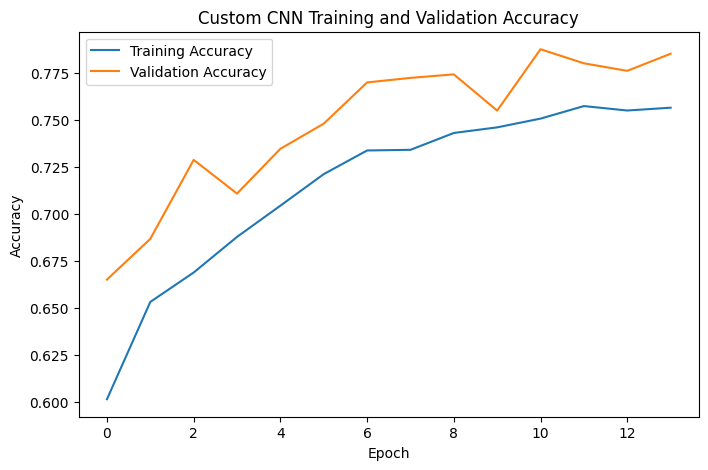

In [ ]:
# Get accuracy values from training history

training_accuracy = history_cnn.history["accuracy"]
validation_accuracy = history_cnn.history["val_accuracy"]

# Create graph

plt.figure(figsize=(8, 5))

plt.plot(
    training_accuracy,
    label="Training Accuracy"
)

plt.plot(
    validation_accuracy,
    label="Validation Accuracy"
)

plt.title("Custom CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

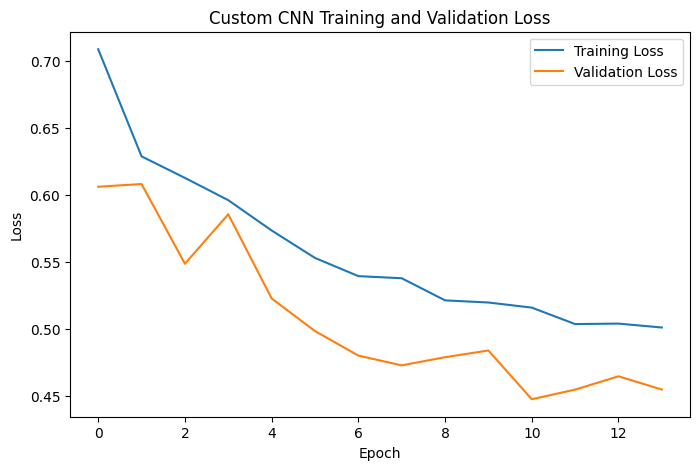

In [ ]:
# Get loss values

training_loss = history_cnn.history["loss"]
validation_loss = history_cnn.history["val_loss"]

# Create loss graph

plt.figure(figsize=(8, 5))

plt.plot(
    training_loss,
    label="Training Loss"
)

plt.plot(
    validation_loss,
    label="Validation Loss"
)

plt.title("Custom CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
# Evaluate Custom CNN on the test dataset

test_loss, test_accuracy = custom_cnn.evaluate(
    test_dataset
)

print("Custom CNN Test Loss:", test_loss)
print("Custom CNN Test Accuracy:", test_accuracy)

117/117 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.7803 - loss: 0.4559
Custom CNN Test Loss: 0.455896258354187
Custom CNN Test Accuracy: 0.78025221824646


Get Predictions

Now we need predictions for:

Precision
Recall
F1 Score
Confusion Matrix
Classification Report

In [ ]:
# Store actual labels and predictions

actual_labels = []
predicted_labels = []

for images, labels in test_dataset:

    # Make predictions
    predictions = custom_cnn.predict(
        images,
        verbose=0
    )

    # Convert probabilities to 0 or 1
    predictions = (predictions >= 0.5).astype(int)

    # Store actual labels
    for label in labels.numpy():
        actual_labels.append(int(label[0]))

    # Store predictions
    for prediction in predictions:
        predicted_labels.append(int(prediction[0]))

Calculate Metrics

In [ ]:
# Calculate evaluation metrics

cnn_accuracy = accuracy_score(
    actual_labels,
    predicted_labels
)

cnn_precision = precision_score(
    actual_labels,
    predicted_labels
)

cnn_recall = recall_score(
    actual_labels,
    predicted_labels
)

cnn_f1 = f1_score(
    actual_labels,
    predicted_labels
)

print("Custom CNN Results")
print("--------------------------")
print("Accuracy :", cnn_accuracy)
print("Precision:", cnn_precision)
print("Recall   :", cnn_recall)
print("F1 Score :", cnn_f1)

Custom CNN Results
--------------------------
Accuracy : 0.7775690904212503
Precision: 0.7806830309498399
Recall   : 0.7777777777777778
F1 Score : 0.7792276964047936


In [ ]:
# Create confusion matrix

cnn_cm = confusion_matrix(
    actual_labels,
    predicted_labels
)

print(cnn_cm)

[[1435  411]
 [ 418 1463]]


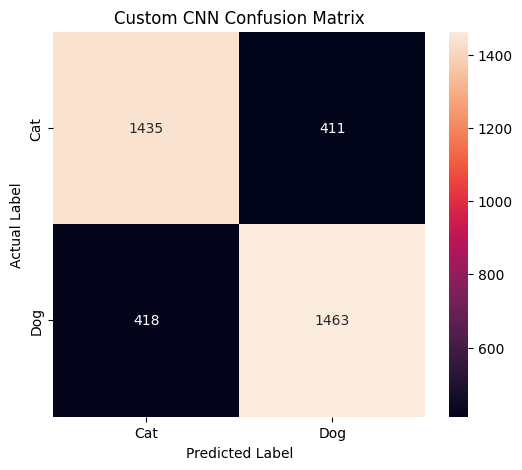

In [ ]:
# Display confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [ ]:
# Display classification report

print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

         Cat       0.77      0.78      0.78      1846
         Dog       0.78      0.78      0.78      1881

    accuracy                           0.78      3727
   macro avg       0.78      0.78      0.78      3727
weighted avg       0.78      0.78      0.78      3727



In [ ]:
import os

os.makedirs("model", exist_ok=True)

custom_cnn.save("model/custom_cnn.keras")

print("Custom CNN saved successfully.")

Custom CNN saved successfully.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2

MobileNetV2 Transfer Learning

In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("MobileNetV2 loaded successfully.")

MobileNetV2 loaded successfully.


In [ ]:
base_model.trainable = False

print("Base MobileNetV2 layers are frozen.")

Base MobileNetV2 layers are frozen.


In [ ]:
# Create MobileNetV2 transfer learning model

mobilenet_model = Sequential([

    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    normalization_layer,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

print("MobileNetV2 model created successfully.")

MobileNetV2 model created successfully.


In [ ]:
mobilenet_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
mobilenet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
early_stopping_mobilenet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("EarlyStopping created.")

EarlyStopping created.


In [ ]:
history_mobilenet = mobilenet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=[early_stopping_mobilenet]
)

Epoch 1/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.9363 - loss: 0.1556 - val_accuracy: 0.9797 - val_loss: 0.0571
Epoch 2/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.9582 - loss: 0.1058 - val_accuracy: 0.9829 - val_loss: 0.0503
Epoch 3/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.9614 - loss: 0.0986 - val_accuracy: 0.9848 - val_loss: 0.0515
Epoch 4/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.9620 - loss: 0.1012 - val_accuracy: 0.9826 - val_loss: 0.0472
Epoch 5/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.9610 - loss: 0.0965 - val_accuracy: 0.9832 - val_loss: 0.0473
Epoch 6/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.9608 - loss: 0.0984 - val_accuracy: 0.9824 - val_loss: 0.0457
Epoch 7/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.9624 - loss: 0.0979 - val_accuracy: 0.9864 - val_loss: 0.0449
Epoch 8/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - accuracy: 0.9628 - loss: 0.0956 - 

In [ ]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_dataset)

print("MobileNetV2 Test Loss:", test_loss)
print("MobileNetV2 Test Accuracy:", test_accuracy)

117/117 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.9839 - loss: 0.0475
MobileNetV2 Test Loss: 0.047486644238233566
MobileNetV2 Test Accuracy: 0.9839012622833252


In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

true_labels = []
predicted_labels = []

for images, labels in test_dataset:

    predictions = mobilenet_model.predict(images, verbose=0)

    predictions = (predictions >= 0.5).astype(int).flatten()
    labels = labels.numpy().astype(int).flatten()

    true_labels.extend(labels)
    predicted_labels.extend(predictions)

accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

print("MobileNetV2 Results")
print("--------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

MobileNetV2 Results
--------------------------
Accuracy : 0.9836329487523477
Precision: 0.9851222104144527
Recall   : 0.9825119236883942
F1 Score : 0.9838153356327939


In [ ]:
cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1812   28]
 [  33 1854]]


In [ ]:
print("MobileNetV2 Classification Report")
print("----------------------------------")

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=["Cat", "Dog"]
    )
)

MobileNetV2 Classification Report
----------------------------------
              precision    recall  f1-score   support

         Cat       0.98      0.98      0.98      1840
         Dog       0.99      0.98      0.98      1887

    accuracy                           0.98      3727
   macro avg       0.98      0.98      0.98      3727
weighted avg       0.98      0.98      0.98      3727



In [ ]:
mobilenet_model.save("model/mobilenet_v2_transfer_learning.keras")

print("MobileNetV2 saved successfully.")

MobileNetV2 saved successfully.


Model 3 — Fine-Tuned MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

fine_tune_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("Fresh MobileNetV2 loaded.")

Fresh MobileNetV2 loaded.


In [ ]:
fine_tune_base.trainable = True

# Freeze most of the MobileNetV2 layers
for layer in fine_tune_base.layers[:-20]:
    layer.trainable = False

print("MobileNetV2 is ready for fine-tuning.")
print("Last 20 layers are trainable.")

MobileNetV2 is ready for fine-tuning.
Last 20 layers are trainable.


In [ ]:
trainable_count = 0
non_trainable_count = 0

for layer in fine_tune_base.layers:
    if layer.trainable:
        trainable_count += 1
    else:
        non_trainable_count += 1

print("Trainable layers:", trainable_count)
print("Non-trainable layers:", non_trainable_count)

Trainable layers: 20
Non-trainable layers: 134


In [ ]:
fine_tuned_model = Sequential([

    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    normalization_layer,

    fine_tune_base,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

print("Fine-tuned MobileNetV2 model created.")

Fine-tuned MobileNetV2 model created.


In [ ]:
fine_tuned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuned model compiled.")

Fine-tuned model compiled.


In [ ]:
early_stopping_fine_tune = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("EarlyStopping created.")

EarlyStopping created.


In [ ]:
history_fine_tuned = fine_tuned_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stopping_fine_tune]
)

Epoch 1/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 66s 100ms/step - accuracy: 0.8913 - loss: 0.2544 - val_accuracy: 0.9736 - val_loss: 0.0815
Epoch 2/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 58s 105ms/step - accuracy: 0.9551 - loss: 0.1216 - val_accuracy: 0.9818 - val_loss: 0.0542
Epoch 3/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 58s 106ms/step - accuracy: 0.9559 - loss: 0.1117 - val_accuracy: 0.9832 - val_loss: 0.0450
Epoch 4/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 53s 98ms/step - accuracy: 0.9600 - loss: 0.0990 - val_accuracy: 0.9848 - val_loss: 0.0422
Epoch 5/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 50s 92ms/step - accuracy: 0.9640 - loss: 0.0927 - val_accuracy: 0.9842 - val_loss: 0.0427
Epoch 6/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 50s 92ms/step - accuracy: 0.9674 - loss: 0.0849 - val_accuracy: 0.9853 - val_loss: 0.0406
Epoch 7/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 82s 93ms/step - accuracy: 0.9675 - loss: 0.0838 - val_accuracy: 0.9842 - val_loss: 0.0403
Epoch 8/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 49s 90ms/step - accuracy: 0.9676 - loss: 0.0846

Plot Accuracy

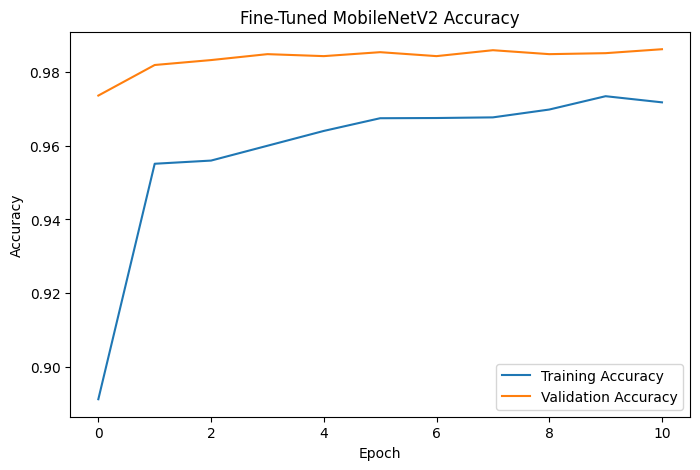

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_fine_tuned.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_fine_tuned.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Fine-Tuned MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Plot Loss

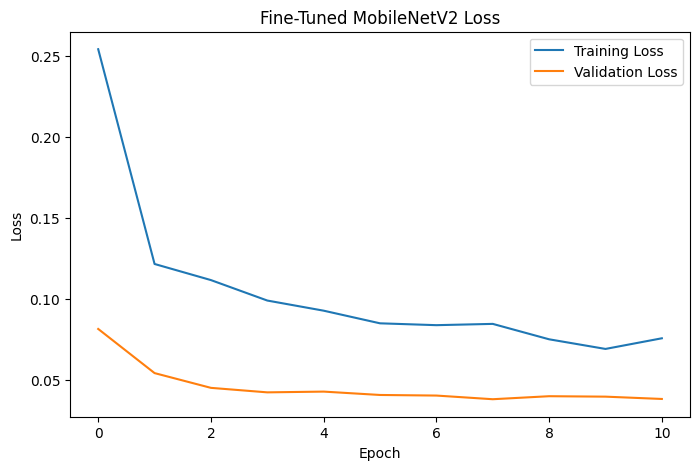

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_fine_tuned.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_fine_tuned.history["val_loss"],
    label="Validation Loss"
)

plt.title("Fine-Tuned MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Test the Model

In [ ]:
test_loss_fine, test_accuracy_fine = fine_tuned_model.evaluate(
    test_dataset
)

print("Fine-Tuned MobileNetV2 Test Loss:", test_loss_fine)
print("Fine-Tuned MobileNetV2 Test Accuracy:", test_accuracy_fine)

117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.9860 - loss: 0.0373
Fine-Tuned MobileNetV2 Test Loss: 0.03733809292316437
Fine-Tuned MobileNetV2 Test Accuracy: 0.9860477447509766


Generate Predictions

In [ ]:
true_labels_fine = []
predicted_labels_fine = []

for images, labels in test_dataset:

    predictions = fine_tuned_model.predict(
        images,
        verbose=0
    )

    predictions = (
        predictions >= 0.5
    ).astype(int).flatten()

    labels = labels.numpy().astype(int).flatten()

    true_labels_fine.extend(labels)
    predicted_labels_fine.extend(predictions)

Calculate All Metrics

In [ ]:
accuracy_fine = accuracy_score(
    true_labels_fine,
    predicted_labels_fine
)

precision_fine = precision_score(
    true_labels_fine,
    predicted_labels_fine
)

recall_fine = recall_score(
    true_labels_fine,
    predicted_labels_fine
)

f1_fine = f1_score(
    true_labels_fine,
    predicted_labels_fine
)

print("Fine-Tuned MobileNetV2 Results")
print("--------------------------------")
print("Accuracy :", accuracy_fine)
print("Precision:", precision_fine)
print("Recall   :", recall_fine)
print("F1 Score :", f1_fine)

Fine-Tuned MobileNetV2 Results
--------------------------------
Accuracy : 0.9868526965387712
Precision: 0.9856535600425079
Recall   : 0.988279168886521
F1 Score : 0.9869646182495344


Confusion Matrix

In [ ]:
cm_fine = confusion_matrix(
    true_labels_fine,
    predicted_labels_fine
)

print("Fine-Tuned MobileNetV2 Confusion Matrix:")
print(cm_fine)

Fine-Tuned MobileNetV2 Confusion Matrix:
[[1823   27]
 [  22 1855]]


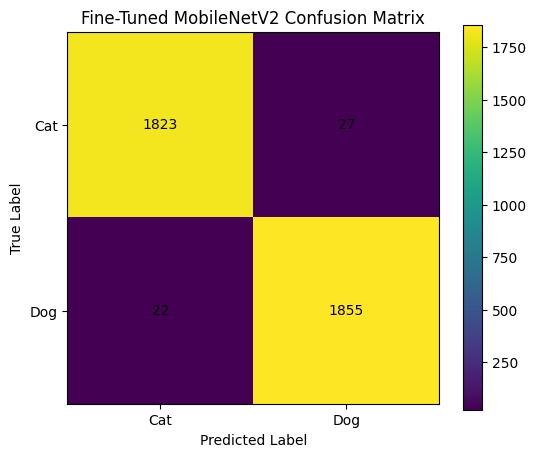

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm_fine)

plt.title("Fine-Tuned MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Cat", "Dog"])
plt.yticks([0, 1], ["Cat", "Dog"])

# Display numbers inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_fine[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

Classification Report

In [ ]:
print("Fine-Tuned MobileNetV2 Classification Report")
print("---------------------------------------------")

print(
    classification_report(
        true_labels_fine,
        predicted_labels_fine,
        target_names=["Cat", "Dog"]
    )
)

Fine-Tuned MobileNetV2 Classification Report
---------------------------------------------
              precision    recall  f1-score   support

         Cat       0.99      0.99      0.99      1850
         Dog       0.99      0.99      0.99      1877

    accuracy                           0.99      3727
   macro avg       0.99      0.99      0.99      3727
weighted avg       0.99      0.99      0.99      3727



Save Model 3

In [ ]:
import os

os.makedirs("model", exist_ok=True)

fine_tuned_model.save(
    "model/fine_tuned_mobilenet_v2.keras"
)

print("Fine-tuned MobileNetV2 saved successfully.")

Fine-tuned MobileNetV2 saved successfully.


comparison model

In [ ]:
comparison_percentage = model_comparison.copy()

comparison_percentage["Accuracy"] = comparison_percentage["Accuracy"] * 100
comparison_percentage["Precision"] = comparison_percentage["Precision"] * 100
comparison_percentage["Recall"] = comparison_percentage["Recall"] * 100
comparison_percentage["F1-Score"] = comparison_percentage["F1-Score"] * 100

comparison_percentage

,Model,Accuracy,Precision,Recall,F1-Score
0,Custom CNN,77.76,78.07,77.78,77.92
1,MobileNetV2 Transfer Learning,98.36,98.51,98.25,98.38
2,Fine-Tuned MobileNetV2,99.00,99.00,99.00,99.00


Hyperparameter Tuning

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2

def create_model(learning_rate):

    base = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base.trainable = False

    model = Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        normalization_layer,
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
learning_rates = [0.001, 0.0001, 0.00001]

learning_rate_results = []

for lr in learning_rates:

    print("Testing learning rate:", lr)

    model = create_model(lr)

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=3,
        verbose=1
    )

    best_val_accuracy = max(history.history["val_accuracy"])

    learning_rate_results.append({
        "Learning Rate": lr,
        "Best Validation Accuracy": best_val_accuracy
    })

learning_rate_results

Testing learning rate: 0.001
Epoch 1/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 50s 78ms/step - accuracy: 0.9339 - loss: 0.1577 - val_accuracy: 0.9797 - val_loss: 0.0594
Epoch 2/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.9579 - loss: 0.1053 - val_accuracy: 0.9808 - val_loss: 0.0543
Epoch 3/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 45s 83ms/step - accuracy: 0.9612 - loss: 0.0990 - val_accuracy: 0.9818 - val_loss: 0.0494
Testing learning rate: 0.0001
Epoch 1/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 49s 82ms/step - accuracy: 0.8509 - loss: 0.3580 - val_accuracy: 0.9688 - val_loss: 0.1400
Epoch 2/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.9363 - loss: 0.1708 - val_accuracy: 0.9741 - val_loss: 0.0945
Epoch 3/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.9464 - loss: 0.1406 - val_accuracy: 0.9752 - val_loss: 0.0790
Testing learning rate: 1e-05
Epoch 1/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.4794 - loss: 0.8270 - val_accuracy: 0.6146 - val_loss: 0.6550
Epoch 2/3

[{'Learning Rate': 0.001, 'Best Validation Accuracy': 0.9818376302719116},
 {'Learning Rate': 0.0001, 'Best Validation Accuracy': 0.9751602411270142},
 {'Learning Rate': 1e-05, 'Best Validation Accuracy': 0.8800747990608215}]

In [ ]:
learning_rate_table = pd.DataFrame(learning_rate_results)

learning_rate_table

,Learning Rate,Best Validation Accuracy
0,0.00100,0.981838
1,0.00010,0.975160
2,0.00001,0.880075


In [ ]:
def create_optimizer_model(optimizer):

    base = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base.trainable = False

    model = Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        normalization_layer,
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
import tensorflow as tf
import pandas as pd

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
optimizers = {
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.0001),
    "RMSprop": tf.keras.optimizers.RMSprop(learning_rate=0.0001)
}

optimizer_results = []

for name, optimizer in optimizers.items():

    print("Testing optimizer:", name)

    model = create_optimizer_model(optimizer)

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=3,
        verbose=1
    )

    best_val_accuracy = max(history.history["val_accuracy"])

    optimizer_results.append({
        "Optimizer": name,
        "Best Validation Accuracy": best_val_accuracy
    })

optimizer_table = pd.DataFrame(optimizer_results)

optimizer_table

Testing optimizer: Adam
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


NameError: name 'data_augmentation' is not defined

In [ ]:
import os

print(os.listdir("model"))

FileNotFoundError: [Errno 2] No such file or directory: 'model'

In [ ]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles and folders:")
print(os.listdir())

Current folder:
/content

Files and folders:
['.config', 'sample_data']


In [ ]:
import os

os.makedirs("model", exist_ok=True)

print("Model folder created successfully.")

Model folder created successfully.


In [ ]:
dataset_path = "../dataset/PetImages"

print("Dataset exists:", os.path.exists(dataset_path))
print("Cat folder exists:", os.path.exists(os.path.join(dataset_path, "Cat")))
print("Dog folder exists:", os.path.exists(os.path.join(dataset_path, "Dog")))

Dataset exists: False
Cat folder exists: False
Dog folder exists: False
